# 실습 3 — 추천 시스템 (Recommendation System)

**MovieLens 데이터셋을 활용한 Content-Based Filtering & Collaborative Filtering 영화 추천 시스템 구축**  
참고: MovieLens는 추천 시스템 연구의 대표적인 벤치마크 데이터셋입니다.  
Utility
Matrix(사용자×영화)의 희소성이 매우 높으며, 이를 효과적으로 채우는 것이 추천 시스
템의 핵심 과제입니다.

---

## 목차
1. 환경 설정 및 데이터 로드
2. **[Task 1]** 데이터 탐색(EDA) & Utility Matrix 분석
3. **[Task 2]** Content-Based Filtering (추가: 장르 + 태그 TF-IDF)
4. **[Task 3]** Collaborative Filtering  
(User-based & Item-based)  
- 유사도 계산  
- 평점 예측  
- 성능 평가  

5. **[Task 4]** 결과 비교 및 인사이트 도출
6. **[추가]** Matrix Factorization (SVD) & SVD++ & NMF 비교
7. **[추가]** Hybrid 추천 시스템 구현
8. 결론 및 논의

---
**데이터셋 출처**:  
GroupLens Research — MovieLens Latest Small
(https://grouplens.org/datasets/movielens/latest/)  

참고: https://grouplens.org/datasets/movielens/32m/ -> 32M 데이터셋이 너무 커서 Colab 무료 버전 RAM이 부족함. 특히 pivot_table로 Utility Matrix 만들 때 메모리가 폭발하여 latest small data 사용함.



## 1. 환경 설정 및 데이터 로드

필요한 라이브러리를 임포트하고, MovieLens Latest Small 데이터셋을 다운로드합니다.  

In [ ]:
#Surprise 라이브러리 설치
!pip install numpy==1.26.4
!pip install scikit-surprise

#1~2분 정도 걸릴 수 있습니다...!
#한번더 재시작(런타임재시작) 눌러주시면 잘 돌아갑니다...!

In [ ]:
#  필수 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 머신러닝 / 유사도 계산
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 희소 행렬
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr

# Surprise 라이브러리 (Matrix Factorization 등)
from surprise import Dataset, Reader, SVD, SVDpp, NMF, KNNBasic
from surprise.model_selection import cross_validate, train_test_split as surprise_split
from surprise import accuracy
print('Surprise 라이브러리 로드 완료!')

import warnings, os, urllib.request, zipfile
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['axes.unicode_minus'] = False

Surprise 라이브러리 로드 완료!


---
## Task 1. 데이터 탐색(EDA) & Utility Matrix 분석

### 분석 흐름
1. ratings.csv 와 movies.csv 를 로드 & 기본 정보 확인 (shape, dtypes, 결측치)
2. 평점 분포 시각화 (히스토그램)
3. 사용자별·영화별 평점 수 분포 (히스토그램 또는 박스플롯)
4. Utility Matrix 생성 & Sparsity 계산
5. 장르별 평균 평점 & 영화 수 비교 (막대그래프)
6. (추가) 연도별 평점 트렌드 분석

In [ ]:
# 1-1. MovieLens Latest Small 데이터셋 다운로드
DATA_DIR = 'ml-latest-small'
ZIP_FILE = 'ml-latest-small.zip'
URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'

if not os.path.exists(DATA_DIR):
    print('데이터 다운로드 중...')
    urllib.request.urlretrieve(URL, ZIP_FILE)
    with zipfile.ZipFile(ZIP_FILE, 'r') as z:
        z.extractall('.')
    print('데이터 다운로드 및 압축 해제 완료!')
else:
    print('데이터가 이미 존재합니다.')


#  CSV 파일 로드
#  ratings.csv : 사용자 평점 데이터
#  movies.csv  : 영화 메타데이터 (제목, 장르)
#  tags.csv    : 사용자 태그 데이터 (추가 태스크)
ratings = pd.read_csv(f'{DATA_DIR}/ratings.csv')
movies  = pd.read_csv(f'{DATA_DIR}/movies.csv')
tags    = pd.read_csv(f'{DATA_DIR}/tags.csv')

print(f'ratings shape : {ratings.shape}')
print(f'movies  shape : {movies.shape}')
print(f'tags    shape : {tags.shape}')
print('\n--- ratings 샘플 ---')
display(ratings.head())
print('\n--- movies 샘플 ---')
display(movies.head())
print('\n--- tags 샘플 ---')
display(tags.head())

데이터가 이미 존재합니다.
ratings shape : (100836, 4)
movies  shape : (9742, 3)
tags    shape : (3683, 4)

--- ratings 샘플 ---


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



--- movies 샘플 ---


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



--- tags 샘플 ---


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [ ]:
#  1-1. 기본 정보 확인
print('=' * 50)
print('[ratings.csv 기본 정보]')
print('=' * 50)
print(ratings.dtypes)
print(f'\n결측치:\n{ratings.isnull().sum()}')
print(f'\n총 평점 수    : {len(ratings):,}')
print(f'고유 사용자 수: {ratings["userId"].nunique():,}')
print(f'고유 영화 수  : {ratings["movieId"].nunique():,}')
print(f'평점 범위     : {ratings["rating"].min()} ~ {ratings["rating"].max()}')
print(f'평균 평점     : {ratings["rating"].mean():.4f}')

print('\n' + '=' * 50)
print('[movies.csv 기본 정보]')
print('=' * 50)
print(movies.dtypes)
print(f'\n결측치:\n{movies.isnull().sum()}')

print('\n' + '=' * 50)
print('[tags.csv 기본 정보]')
print('=' * 50)
print(tags.dtypes)
print(f'\n결측치:\n{tags.isnull().sum()}')

[ratings.csv 기본 정보]
userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

결측치:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

총 평점 수    : 100,836
고유 사용자 수: 610
고유 영화 수  : 9,724
평점 범위     : 0.5 ~ 5.0
평균 평점     : 3.5016

[movies.csv 기본 정보]
movieId     int64
title      object
genres     object
dtype: object

결측치:
movieId    0
title      0
genres     0
dtype: int64

[tags.csv 기본 정보]
userId        int64
movieId       int64
tag          object
timestamp     int64
dtype: object

결측치:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


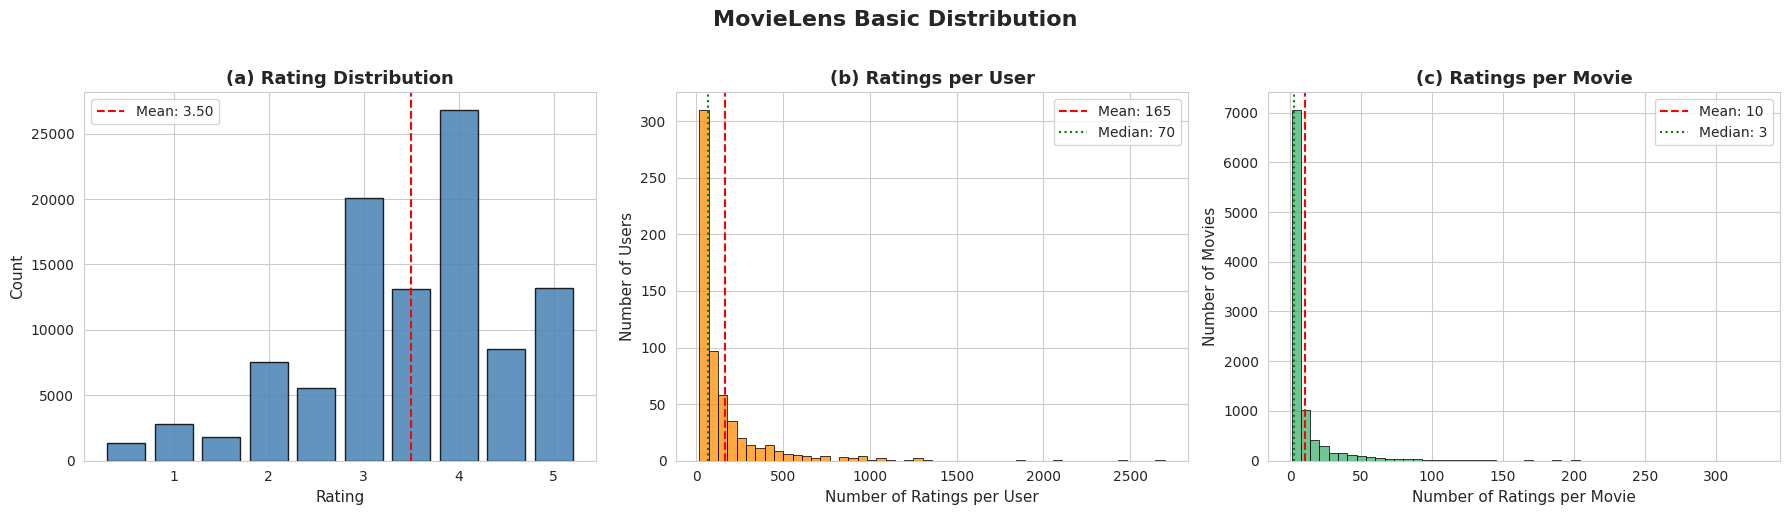

In [ ]:
# 1-2. 평점(rating)의 분포 시각화 (추가: seaborn + matplotlib)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MovieLens Basic Distribution', fontsize=16, fontweight='bold', y=1.02)

# 평점 분포 히스토그램
# 0.5 단위로 나뉘어지므로 bins=10 사용
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            width=0.4, color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('(a) Rating Distribution', fontsize=13, fontweight='bold')

axes[0].set_xlabel('Rating', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].axvline(ratings['rating'].mean(), color='red', linestyle='--',
                label=f'Mean: {ratings["rating"].mean():.2f}')
axes[0].legend(fontsize=10)

# 1-3. 사용자별 평점 수와 영화별 평점 수의 분포

# 사용자별 평점 수 분포
user_counts = ratings.groupby('userId').size()
sns.histplot(user_counts, bins=50, ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('(b) Ratings per User', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings per User', fontsize=11)
axes[1].set_ylabel('Number of Users', fontsize=11)
axes[1].axvline(user_counts.mean(), color='red', linestyle='--',
                label=f'Mean: {user_counts.mean():.0f}')
axes[1].axvline(user_counts.median(), color='green', linestyle=':',
                label=f'Median: {user_counts.median():.0f}')
axes[1].legend(fontsize=10)

# 영화별 평점 수 분포
movie_counts = ratings.groupby('movieId').size()
sns.histplot(movie_counts, bins=50, ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('(c) Ratings per Movie', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of Ratings per Movie', fontsize=11)
axes[2].set_ylabel('Number of Movies', fontsize=11)
axes[2].axvline(movie_counts.mean(), color='red', linestyle='--',
                label=f'Mean: {movie_counts.mean():.0f}')
axes[2].axvline(movie_counts.median(), color='green', linestyle=':',
                label=f'Median: {movie_counts.median():.0f}')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  1-4. Utility Matrix 생성 & Sparsity 계산
#  Utility Matrix = 사용자 × 영화 피벗 테이블
#  대부분의 셀이 비어있는 희소(Sparse) 구조
#  -> 메모리 효율을 위해 scipy.sparse 활용
# 피벗 테이블 생성 (행=사용자, 열=영화, 값=평점)
utility_matrix = ratings.pivot_table(
    index='userId', columns='movieId', values='rating'
)

n_users  = utility_matrix.shape[0]   # 사용자 수
n_movies = utility_matrix.shape[1]   # 영화 수
n_ratings = ratings.shape[0]         # 실제 평점 수

# Sparsity = 빈 셀의 비율
# Sparsity = 1 - (평점 수) / (사용자 수 × 영화 수)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f'Utility Matrix 크기: {n_users} × {n_movies} = {n_users*n_movies:,} 셀')
print(f'실제 평점 수        : {n_ratings:,}')
print(f'희소성 (Sparsity)   : {sparsity:.4%}')  #소수점 4자리
print(f'\n→ 전체 가능한 평점의 {(1-sparsity):.4%}만 관측됨')
print(f'→ {sparsity:.4%}의 셀은 비어있음') #Cold-Start, Sparsity 문제의 원인!!

# scipy.sparse로 변환
# NaN → 0으로 채운 뒤 희소 행렬로 변환
utility_filled = utility_matrix.fillna(0)
utility_sparse = csr_matrix(utility_filled.values)
print(f'\n희소 행렬 저장 크기: {utility_sparse.data.nbytes / 1024:.1f} KB')

Utility Matrix 크기: 610 × 9724 = 5,931,640 셀
실제 평점 수        : 100,836
희소성 (Sparsity)   : 98.3000%

→ 전체 가능한 평점의 1.7000%만 관측됨
→ 98.3000%의 셀은 비어있음

희소 행렬 저장 크기: 787.8 KB


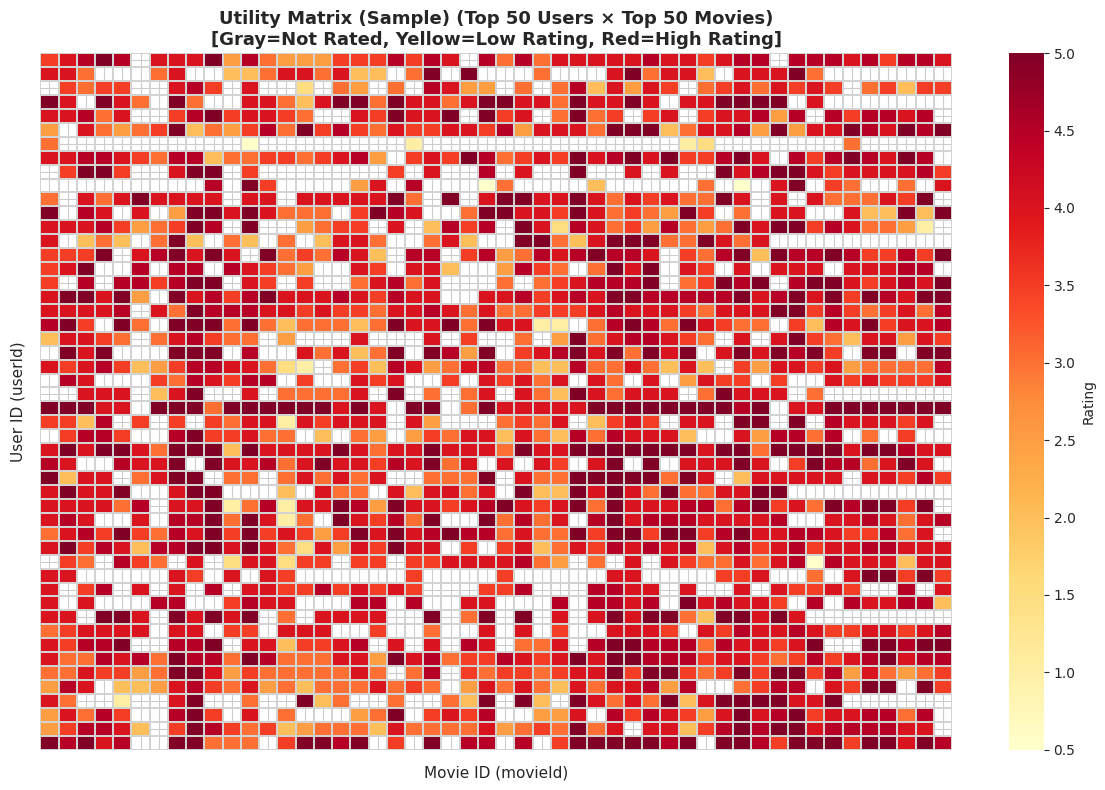

샘플 희소성: 22.28%


In [ ]:
#  1-4. Utility Matrix 시각화 (일부 샘플)

#  전체 행렬은 너무 크므로 상위 50명 × 50개 영화로 시각화
# 평점 수가 많은 상위 50명 사용자, 상위 50개 영화 선택

top_users  = user_counts.nlargest(50).index
top_movies = movie_counts.nlargest(50).index

sample_matrix = utility_matrix.loc[
    utility_matrix.index.isin(top_users),
    utility_matrix.columns.isin(top_movies)
]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    sample_matrix,
    cmap='YlOrRd',
    mask=sample_matrix.isnull(),   # 빈 칸은 마스크
    linewidths=0.3,
    linecolor='lightgray',
    ax=ax,
    cbar_kws={'label': 'Rating'}
)
ax.set_title(
    f'Utility Matrix (Sample) (Top 50 Users × Top 50 Movies)\n'    #상위 50명 사용자×상위 50개 영화
    f'[Gray=Not Rated, Yellow=Low Rating, Red=High Rating]',    #회색=미평가, 노랑= 낮은 평점 빨강=높은 평점
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Movie ID (movieId)', fontsize=11)
ax.set_ylabel('User ID (userId)', fontsize=11)
ax.set_xticklabels([])
ax.set_yticklabels([])
plt.tight_layout()
plt.savefig('fig2_utility_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'샘플 희소성: {sample_matrix.isnull().sum().sum() / sample_matrix.size:.2%}')

In [ ]:
#  1-5. 장르별 평균 평점 & 영화 수 분석

#  장르가 '|'로 구분되어 있으므로 분리 후 분석
# 영화-장르 매핑 (한 영화가 여러 장르에 해당)

genre_df = movies.copy()
genre_df = genre_df.assign(
    genre=genre_df['genres'].str.split('|')
).explode('genre')  # 장르별로 행 분리
genre_df = genre_df[genre_df['genre'] != '(no genres listed)']  # 장르 없는 행 제거

# ratings와 병합하여 장르별 평점 정보 확보
genre_ratings = genre_df.merge(ratings[['movieId', 'rating']], on='movieId', how='left')

# 장르별 집계
genre_stats = genre_ratings.groupby('genre').agg(
    avg_rating=('rating', 'mean'),
    movie_count=('movieId', 'nunique'),
    rating_count=('rating', 'count')
).reset_index().sort_values('avg_rating', ascending=False)

print(genre_stats.to_string(index=False))

      genre  avg_rating  movie_count  rating_count
  Film-Noir    3.920115           87           870
        War    3.808294          382          4859
Documentary    3.797785          440          1219
      Crime    3.658294         1199         16681
      Drama    3.656184         4361         41928
    Mystery    3.632460          573          7674
  Animation    3.629937          611          6988
       IMAX    3.618335          158          4145
    Western    3.583938          167          1930
    Musical    3.563678          334          4138
  Adventure    3.508609         1263         24161
    Romance    3.506511         1596         18124
   Thriller    3.493706         1894         26452
    Fantasy    3.491001          779         11834
     Sci-Fi    3.455721          980         17243
     Action    3.447984         1828         30635
   Children    3.412956          664          9208
     Comedy    3.384721         3756         39053
     Horror    3.258195        

In [ ]:
# 1-5. 장르별 시각화 (추가: Plotly 고급 시각화 활용)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        '장르별 평균 평점 (내림차순)',
        '장르별 영화 수'
    )
)

# 평균 평점 막대그래프
fig.add_trace(
    go.Bar(
        x=genre_stats['avg_rating'],
        y=genre_stats['genre'],
        orientation='h',
        marker_color=genre_stats['avg_rating'],
        marker_colorscale='Viridis',
        name='평균 평점',
        text=genre_stats['avg_rating'].round(2),
        textposition='outside'
    ),
    row=1, col=1
)

# 영화 수 막대그래프
genre_stats_sorted = genre_stats.sort_values('movie_count', ascending=False)
fig.add_trace(
    go.Bar(
        x=genre_stats_sorted['movie_count'],
        y=genre_stats_sorted['genre'],
        orientation='h',
        marker_color=genre_stats_sorted['movie_count'],
        marker_colorscale='Cividis',
        name='영화 수',
        text=genre_stats_sorted['movie_count'],
        textposition='outside'
    ),
    row=1, col=2
)

fig.update_layout(
    title_text='<b>장르별 평균 평점 & 영화 수 비교</b>',
    height=600,
    showlegend=False,
    font=dict(size=12)
)
fig.update_xaxes(title_text='평균 평점', row=1, col=1)
fig.update_xaxes(title_text='영화 수', row=1, col=2)
fig.show()

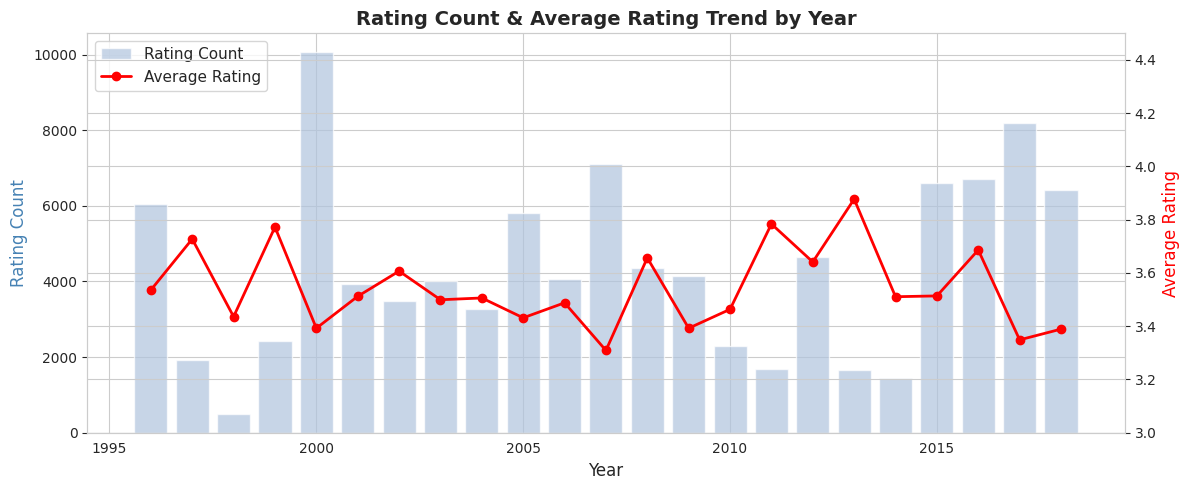

In [ ]:
#  1-6. 연도별 평점 트렌드 (추가 인사이트)
#  timestamp를 datetime으로 변환 후 연도별 분석
ratings['year'] = pd.to_datetime(ratings['timestamp'], unit='s').dt.year
year_stats = ratings.groupby('year').agg(
    avg_rating=('rating', 'mean'),
    count=('rating', 'count')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()  # 이중 축

ax1.bar(year_stats['year'], year_stats['count'],
        color='lightsteelblue', alpha=0.7, label='Rating Count')  # 평점 수
ax2.plot(year_stats['year'], year_stats['avg_rating'],
         'ro-', linewidth=2, markersize=6, label='Average Rating')  # 평균 평점

ax1.set_xlabel('Year', fontsize=12)  #연도
ax1.set_ylabel('Rating Count', fontsize=12, color='steelblue') #평점 수
ax2.set_ylabel('Average Rating', fontsize=12, color='red') #평균 평점
ax2.set_ylim(3.0, 4.5)

# 두 레전드(범례) 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.title('Rating Count & Average Rating Trend by Year', fontsize=14, fontweight='bold') #연도별 평점 수 & 평균 평점 트렌드
plt.tight_layout()
plt.savefig('fig3_year_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 2. Content-Based Filtering

### 개념 설명
- **Content-Based Filtering**: 아이템(영화)의 **속성(장르, 태그)을 벡터화**하여,  
  사용자가 좋아한 영화와 **코사인 유사도**가 높은 영화를 추천하는 방식
- **TF-IDF**: Term Frequency-Inverse Document Frequency  
  -> 자주 등장하지만 너무 흔하지 않은 단어에 높은 가중치 부여

### 분석 흐름
1. **추가**: tags.csv를 활용하여 장르+태그 결합 Content Profile 구축
2. TF-IDF 벡터화 -> 코사인 유사도 계산
3. 영화 기반 추천 (Item Profiles 구축)
4. 사용자 기반 추천 (User Profiles 구축)
5. Content-Based Filtering 의 장점과 한계를 실습 결과를 바탕으로 논의

In [ ]:
#  2-1. Content Profile 구축 (장르 + 태그 결합)

#  장르: '|' 구분자 제거 후 공백으로 연결

#  [추가] tags.csv를 활용하여 영화 프로필을 풍부하게 구성
#  태그: 사용자가 붙인 키워드

# 장르 전처리: '|' → 공백 (TF-IDF 입력을 위해 단어 단위 분리)
movies['genres_clean'] = movies['genres'].str.replace('|', ' ', regex=False)\
                                          .str.replace('(no genres listed)', '', regex=False)\
                                          .str.strip()

# 태그 전처리: 영화별 태그를 하나의 문자열로 결합
tags_clean = tags.dropna(subset=['tag'])  # 결측 태그 제거
tags_clean['tag'] = tags_clean['tag'].str.lower().str.strip()  # 소문자 정규화
movie_tags = tags_clean.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
movie_tags.columns = ['movieId', 'tags_str']

# movies와 태그 병합
movies_enhanced = movies.merge(movie_tags, on='movieId', how='left')
movies_enhanced['tags_str'] = movies_enhanced['tags_str'].fillna('')  # 태그 없는 영화는 빈 문자열

# 최종 Content Profile = 장르 + 태그
#가중치: 장르 2배 반복으로 중요도 강조
#장르는 객관적 정보, 태그는 주관적이라 장르를 더 중요하게 보는 게 합리적이라고 판단함.
movies_enhanced['content'] = (
    movies_enhanced['genres_clean'] + ' '
    + movies_enhanced['genres_clean'] + ' '
    + movies_enhanced['tags_str']
)

print(f'Content Profile이 있는 영화 수: {(movies_enhanced["content"].str.strip() != "").sum()}')
print(f'태그가 있는 영화 수          : {(movies_enhanced["tags_str"] != "").sum()}')
print('\n--- 샘플 영화 Content Profile ---')
display(movies_enhanced[['title', 'genres_clean', 'tags_str', 'content']].head(5))

Content Profile이 있는 영화 수: 9709
태그가 있는 영화 수          : 1572

--- 샘플 영화 Content Profile ---


,title,genres_clean,tags_str,content
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy,pixar pixar fun,Adventure Animation Children Comedy Fantasy Ad...
1,Jumanji (1995),Adventure Children Fantasy,fantasy magic board game robin williams game,Adventure Children Fantasy Adventure Children ...
2,Grumpier Old Men (1995),Comedy Romance,moldy old,Comedy Romance Comedy Romance moldy old
3,Waiting to Exhale (1995),Comedy Drama Romance,,Comedy Drama Romance Comedy Drama Romance
4,Father of the Bride Part II (1995),Comedy,pregnancy remake,Comedy Comedy pregnancy remake


In [ ]:
#  2-2. TF-IDF 벡터화 & 코사인 유사도 계산

#  TF-IDF: 각 단어의 중요도를 수치화
#  코사인 유사도: 두 벡터 간 각도의 코사인값 (0~1, 클수록 유사)

# TF-IDF 벡터라이저 설정
# min_df=2: 2개 이상 영화에 등장한 단어만 포함 (노이즈 감소)
# max_features=5000: 상위 5000개 단어만 사용
tfidf = TfidfVectorizer(
    min_df=2,
    max_features=5000,
    strip_accents='ascii',
    analyzer='word',
    token_pattern=r'\w{1,}',
    ngram_range=(1, 2),   # 단어 1~2개 조합도 고려 (예: 'science fiction')
    stop_words='english'  # 영어 불용어 제거
)

# TF-IDF 행렬 생성 (영화 수 × 단어 수)
tfidf_matrix = tfidf.fit_transform(movies_enhanced['content'])
print(f'TF-IDF 행렬 크기: {tfidf_matrix.shape}  => (영화 수, 단어 수)')
print(f'TF-IDF 행렬 타입: {type(tfidf_matrix)} (희소 행렬)')

# 코사인 유사도 계산 (linear_kernel = 정규화된 TF-IDF에서 코사인 유사도와 동일)
# 메모리 효율: cosine_similarity보다 linear_kernel이 TF-IDF에서 더 빠름
cosine_sim_cb = linear_kernel(tfidf_matrix, tfidf_matrix)
print(f'\n코사인 유사도 행렬 크기: {cosine_sim_cb.shape} =>(영화 수 × 영화 수)')
print(f'대각선 값 (자기 자신과의 유사도): {cosine_sim_cb[0, 0]:.4f}') # 1.0이어야 함

# 영화 제목 → 인덱스 매핑 딕셔너리
movie_idx = pd.Series(
    movies_enhanced.index,
    index=movies_enhanced['title']
)

TF-IDF 행렬 크기: (9742, 1583)  => (영화 수, 단어 수)
TF-IDF 행렬 타입: <class 'scipy.sparse._csr.csr_matrix'> (희소 행렬)

코사인 유사도 행렬 크기: (9742, 9742) =>(영화 수 × 영화 수)
대각선 값 (자기 자신과의 유사도): 1.0000


In [ ]:
#  2-3. 영화 기반 추천 함수 (Item Profiles)
# 특정 영화 1 개를 선택하고, 해당 영화와 가장 유사한 상위 10 개 영화를 추천

def get_similar_movies(title, top_n=10, verbose=True):
    """
    주어진 영화 제목과 가장 유사한 영화를 추천합니다.

    Parameters:
        title  : 기준 영화 제목 (문자열)
        top_n  : 추천할 영화 수 (기본값: 10)
        verbose: 결과 출력 여부
    Returns:
        추천 영화 DataFrame
    """
    # 제목으로 인덱스 탐색
    if title not in movie_idx:
        print(f'오류: "{title}" 영화를 찾을 수 없습니다.')
        return None

    idx = movie_idx[title]  # 해당 영화의 인덱스

    # 모든 영화와의 코사인 유사도 추출
    sim_scores = list(enumerate(cosine_sim_cb[idx]))

    # 유사도 내림차순 정렬 (자기 자신 제외)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [(i, s) for i, s in sim_scores if i != idx][:top_n]

    # 결과 DataFrame 생성
    rec_indices = [i for i, _ in sim_scores]
    rec_scores  = [s for _, s in sim_scores]

    result = movies_enhanced.iloc[rec_indices][['title', 'genres_clean', 'tags_str']].copy()
    result['cosine_similarity'] = rec_scores
    result = result.reset_index(drop=True)
    result.index += 1  # 1부터 시작

    if verbose:
        print(f'\n[기준 영화] {title}')
        print(f'장르: {movies_enhanced.iloc[idx]["genres_clean"]}')
        print('=' * 70)
        print(f'Content-Based 추천 영화 Top {top_n}:')
        print('=' * 70)
        for rank, row in result.iterrows():
            print(f'{rank:2d}. [{row["cosine_similarity"]:.3f}] {row["title"]} | {row["genres_clean"]}')

    return result


# ─── 테스트: Toy Story (1995) 추천 ───
rec1 = get_similar_movies('Toy Story (1995)', top_n=10)


[기준 영화] Toy Story (1995)
장르: Adventure Animation Children Comedy Fantasy
Content-Based 추천 영화 Top 10:
 1. [0.798] Bug's Life, A (1998) | Adventure Animation Children Comedy
 2. [0.783] Antz (1998) | Adventure Animation Children Comedy Fantasy
 3. [0.783] Adventures of Rocky and Bullwinkle, The (2000) | Adventure Animation Children Comedy Fantasy
 4. [0.783] Emperor's New Groove, The (2000) | Adventure Animation Children Comedy Fantasy
 5. [0.783] Monsters, Inc. (2001) | Adventure Animation Children Comedy Fantasy
 6. [0.783] Wild, The (2006) | Adventure Animation Children Comedy Fantasy
 7. [0.783] Shrek the Third (2007) | Adventure Animation Children Comedy Fantasy
 8. [0.783] Tale of Despereaux, The (2008) | Adventure Animation Children Comedy Fantasy
 9. [0.783] Asterix and the Vikings (Astérix et les Vikings) (2006) | Adventure Animation Children Comedy Fantasy
10. [0.783] Turbo (2013) | Adventure Animation Children Comedy Fantasy


In [ ]:
#  2-3. 추가 테스트: 장르가 다른 영화로 추천 확인
rec2 = get_similar_movies('Pulp Fiction (1994)', top_n=10)


[기준 영화] Pulp Fiction (1994)
장르: Comedy Crime Drama Thriller
Content-Based 추천 영화 Top 10:
 1. [0.380] Big Lebowski, The (1998) | Comedy Crime
 2. [0.311] Reservoir Dogs (1992) | Crime Mystery Thriller
 3. [0.291] Movie 43 (2013) | Comedy
 4. [0.246] Fight Club (1999) | Action Crime Drama Thriller
 5. [0.235] Kiss Kiss Bang Bang (2005) | Comedy Crime Mystery Thriller
 6. [0.225] Django Unchained (2012) | Action Drama Western
 7. [0.221] The Hateful Eight (2015) | Western
 8. [0.218] Léon: The Professional (a.k.a. The Professional) (Léon) (1994) | Action Crime Drama Thriller
 9. [0.214] 12 Angry Men (1957) | Drama
10. [0.209] Sleeping with the Enemy (1991) | Drama Thriller


In [ ]:
#  2-4. 사용자 기반 Content-Based 추천 (User Profiles)
# 특정 사용자 1 명을 선택하고, 해당 사용자가 높게 평가한 영화를 기반으로 User Profile을 구축한 뒤, 사용자에게 영화를 추천

#  1. 사용자가 높게 평가한 영화(4.0 이상) 목록 추출
#  2. 해당 영화들의 TF-IDF 벡터를 평점 가중 평균 -> User Profile
#  3. User Profile과 코사인 유사도 높은 영화 추천

def build_user_profile(user_id, rating_threshold=4.0):
    """
    사용자의 User Profile 벡터를 생성합니다.
    고평점 영화들의 TF-IDF 벡터를 평점 가중 평균하여 생성.
    """
    # 해당 사용자의 평점 데이터
    user_ratings = ratings[ratings['userId'] == user_id]

    # 임계값 이상 평점 영화만 선택 (없으면 3.5 이상으로 완화)
    liked = user_ratings[user_ratings['rating'] >= rating_threshold]
    if len(liked) == 0:
        liked = user_ratings[user_ratings['rating'] >= 3.5]

    liked = liked.merge(movies_enhanced[['movieId']], on='movieId', how='inner')

    if len(liked) == 0:
        return None, []

    # 영화 인덱스 → TF-IDF 행에 접근
    movie_id_to_idx = pd.Series(
        movies_enhanced.index, index=movies_enhanced['movieId']
    )

    liked_indices = [movie_id_to_idx.get(mid) for mid in liked['movieId'] if mid in movie_id_to_idx.index]
    liked_ratings = liked.set_index('movieId')['rating']

    if not liked_indices:
        return None, []

    # TF-IDF 가중 평균으로 User Profile 생성
    tfidf_subset = tfidf_matrix[liked_indices]  # 고평점 영화의 TF-IDF 벡터
    weights = np.array([liked_ratings.get(movies_enhanced.iloc[i]['movieId'], 1.0)
                        for i in liked_indices])
    weights = weights / weights.sum()  # 정규화

    # 가중 평균 User Profile
    user_profile = tfidf_subset.T.dot(weights)   # (단어 수,) 벡터

    return user_profile, liked['movieId'].tolist()


def user_content_recommend(user_id, top_n=10, rating_threshold=4.0):
    """
    사용자에게 Content-Based Filtering으로 영화를 추천합니다.
    """
    user_profile, seen_movie_ids = build_user_profile(user_id, rating_threshold)

    if user_profile is None:
        print(f'User {user_id}: 프로필을 구성할 수 있는 평점 데이터가 없습니다.')
        return None

    # User Profile과 모든 영화 간 코사인 유사도 계산
    # user_profile이 numpy array이면 reshape 필요
    if hasattr(user_profile, 'toarray'):
        user_vec = np.asarray(user_profile).reshape(1, -1)
    else:
        user_vec = np.asarray(user_profile).reshape(1, -1)

    sim_scores = cosine_similarity(user_vec, tfidf_matrix).flatten()

    # 이미 본 영화 제외
    movie_id_to_idx = pd.Series(movies_enhanced.index, index=movies_enhanced['movieId'])
    seen_indices = [movie_id_to_idx.get(mid) for mid in seen_movie_ids
                    if mid in movie_id_to_idx.index]
    sim_scores[seen_indices] = -1  # 이미 본 영화는 점수를 -1로 설정

    # 상위 N개 추천
    top_indices = sim_scores.argsort()[::-1][:top_n]

    result = movies_enhanced.iloc[top_indices][['movieId', 'title', 'genres_clean']].copy()
    result['cb_score'] = sim_scores[top_indices]
    result = result.reset_index(drop=True)
    result.index += 1

    print(f'\n[User {user_id}] Content-Based 추천 Top {top_n}')
    print(f'(기반: 평점 {rating_threshold} 이상 영화 {len(seen_movie_ids)}편)')
    print('=' * 70)
    for rank, row in result.iterrows():
        print(f'{rank:2d}. [{row["cb_score"]:.4f}] {row["title"]} | {row["genres_clean"]}')

    return result


# 테스트: User 1에게 추천
cb_rec_user1 = user_content_recommend(user_id=1, top_n=10)


[User 1] Content-Based 추천 Top 10
(기반: 평점 4.0 이상 영화 200편)
 1. [0.5851] Twelve Tasks of Asterix, The (Les douze travaux d'Astérix) (1976) | Action Adventure Animation Children Comedy Fantasy
 2. [0.5851] TMNT (Teenage Mutant Ninja Turtles) (2007) | Action Adventure Animation Children Comedy Fantasy
 3. [0.5790] Ratchet & Clank (2016) | Action Adventure Animation Children Comedy Sci-Fi
 4. [0.5790] Chicken Little (2005) | Action Adventure Animation Children Comedy Sci-Fi
 5. [0.5607] G.I. Joe: The Movie (1987) | Action Adventure Animation Children Fantasy Sci-Fi
 6. [0.5607] Batman/Superman Movie, The (1998) | Action Adventure Animation Children Fantasy Sci-Fi
 7. [0.5524] The Great Train Robbery (1978) | Action Adventure Comedy Crime Drama
 8. [0.5524] Flashback (1990) | Action Adventure Comedy Crime Drama
 9. [0.5511] Maximum Ride (2016) | Action Adventure Comedy Fantasy Sci-Fi Thriller
10. [0.5500] Meet the Robinsons (2007) | Action Adventure Animation Children Comedy Sci-Fi


In [ ]:
#  2-4. User 1의 고평점 영화 확인 (추천 타당성 검증)
user1_liked = ratings[
    (ratings['userId'] == 1) & (ratings['rating'] >= 4.0)
].merge(movies[['movieId', 'title', 'genres']], on='movieId')\
 .sort_values('rating', ascending=False)

print('[User 1] 평점 4.0 이상 영화 목록 (User Profile 기반 영화)')
print('=' * 70)
for _, row in user1_liked.iterrows():
    print(f'  {row["rating"]:3.1f}점  {row["title"]} | {row["genres"]}')

# Overspecialization 비율 계산
liked_genres = user1_liked['genres'].str.split('|').explode().value_counts()
rec_genres = cb_rec_user1['genres_clean'].str.split().explode().value_counts()

liked_set = set(liked_genres.index)
rec_set   = set(rec_genres.index)
overlap   = liked_set & rec_set

print(f'\n고평점 영화 고유 장르 수 : {len(liked_set)}')
print(f'CB 추천 영화 고유 장르 수: {len(rec_set)}')
print(f'겹치는 장르              : {overlap}')
print(f'Overspecialization 비율  : {len(overlap)/len(rec_set)*100:.1f}%')
print('→ 100%에 가까울수록 추천이 사용자가 이미 좋아한 장르에만 집중됨')

[User 1] 평점 4.0 이상 영화 목록 (User Profile 기반 영화)
  5.0점  M*A*S*H (a.k.a. MASH) (1970) | Comedy|Drama|War
  5.0점  Who Framed Roger Rabbit? (1988) | Adventure|Animation|Children|Comedy|Crime|Fantasy|Mystery
  5.0점  Spaceballs (1987) | Comedy|Sci-Fi
  5.0점  Newton Boys, The (1998) | Crime|Drama
  5.0점  Thunderball (1965) | Action|Adventure|Thriller
  5.0점  All Quiet on the Western Front (1930) | Action|Drama|War
  5.0점  Rocky (1976) | Drama
  5.0점  Live and Let Die (1973) | Action|Adventure|Thriller
  5.0점  Goonies, The (1985) | Action|Adventure|Children|Comedy|Fantasy
  5.0점  Terminator, The (1984) | Action|Sci-Fi|Thriller
  5.0점  Bambi (1942) | Animation|Children|Drama
  5.0점  Fight Club (1999) | Action|Crime|Drama|Thriller
  5.0점  Black Cauldron, The (1985) | Adventure|Animation|Children|Fantasy
  5.0점  Dr. No (1962) | Action|Adventure|Thriller
  5.0점  Great Mouse Detective, The (1986) | Action|Animation|Children|Crime
  5.0점  From Russia with Love (1963) | Action|Adventure|Thriller
  5.0

#  2-5. Content-Based Filtering 장단점 분석 (보고서에 더 자세히 작성할 예정)
  Content-Based Filtering — 장단점 분석

【 장점 】
1. No cold-start :
   - 새 사용자가 단 1편만 평가해도 즉시 추천 가능
   - 다른 사용자 데이터 불필요

2. Able to recommend new and unpopular items :
   - 평점 수가 적은 영화도 장르+태그 유사도만 높으면 추천 목록에 포함됨

3. Can provide explanations of recommended items by listing contentfeatures that caused an item to be recommended:
   - cosine_similarity 점수와 장르 정보로 "왜 추천됐는지" 확인 가능함

【 한계 】
1. Overspecialization (과특화):
   - 사용자가 본 장르와 유사한 영화만 추천 → 다양성 부족
   → 실습 결과에서도 Overspecialization 비율 100% → User 1이 본 적 없는 장르는 단 하나도 추천되지 않음

2. Recommendations for new users :
   - 평점이 아예 없는 사용자는 User Profile 자체를 만들 수 없음


---
## Task 3. Collaborative Filtering

### 개념 설명
- **Collaborative Filtering**: 사용자의 **평점 패턴(행동)을 기반으로** 유사 사용자/아이템을 찾아 추천
- **User-based CF**: 나와 비슷하게 영화를 평가한 다른 사용자가 좋아하는 영화를 추천
- **Item-based CF**: 내가 좋아한 영화와 비슷하게 평가받는 영화를 추천
- RMSE(Root Mean Squared Error)= sqrt(mean((실제 평점 - 예측 평점)²))
-  MAE(Mean Absolute Error)

### 분석 흐름
3-1. 유사도 계산  
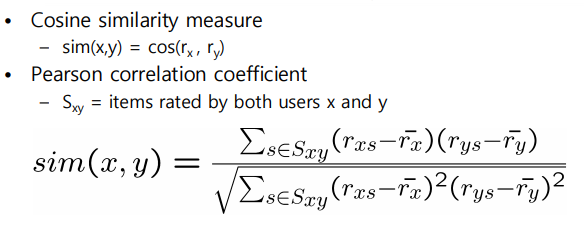  
(코사인 유사도 또는 피어슨 상관계수)
*   User-based CF: 사용자 간 유사도를 계산
*   Item-based CF: 아이템 간 유사도를 계산
*   가장 유사한 사용자(또는 아이템) 상위 K 명(개)을 확인하고, 결과가 합리적인지
검토


3-2. KNN 기반 평점 예측  


*   특정 사용자에 대해 아직 보지 않은 영화의 예측 평점을 산출하고, 상위 10 개를
추천
*   K 값(예: 5, 10, 20, 50)을 변경하며 예측 성능이 어떻게 변하는지 비교


3-3. K값 변화에 따른 성능 비교

*   RMSE/MAE 산출




In [ ]:
#  3-1-1. Train/Test 분리 (80:20)
#  사용자별로 80%는 학습, 20%는 테스트에 사용

#  -> 무작위 분리 시 cold-start 문제 발생할 수 있으므로
#     각 사용자에게 최소 1개 이상의 테스트 데이터 보장

np.random.seed(42)  # 재현성을 위한 랜덤 시드

train_list, test_list = [], []

for uid, group in ratings.groupby('userId'):
    if len(group) < 5:  # 평점이 5개 미만인 사용자는 전부 학습에 사용
        train_list.append(group)
        continue
    # 사용자별 80/20 분리
    train_g, test_g = train_test_split(group, test_size=0.2, random_state=42)
    train_list.append(train_g)
    test_list.append(test_g)

train_df = pd.concat(train_list).reset_index(drop=True)
test_df  = pd.concat(test_list).reset_index(drop=True)

print(f'학습 데이터: {len(train_df):,}건 ({len(train_df)/len(ratings)*100:.1f}%)')
print(f'테스트 데이터: {len(test_df):,}건 ({len(test_df)/len(ratings)*100:.1f}%)')

# --- 학습 데이터로 Utility Matrix 재구성 ---
train_matrix = train_df.pivot_table(
    index='userId', columns='movieId', values='rating'
)
print(f'\n학습 Utility Matrix: {train_matrix.shape}')

학습 데이터: 80,419건 (79.8%)
테스트 데이터: 20,417건 (20.2%)

학습 Utility Matrix: (610, 8965)


In [ ]:
#  3-1-2. User-based CF: 사용자 간 코사인 유사도 계산
#  A. 코사인 유사도
#  B. 피어슨 상관계수

#  Utility Matrix에서 각 행(사용자)을 벡터로 표현
#  NaN은 0으로 채운 후 코사인 유사도 계산

# NaN -> 0 (평점이 없는 경우 0으로 처리)
train_filled = train_matrix.fillna(0)


#====================================================
# A. 코사인 유사도 행렬 계산 (사용자 수 × 사용자 수)
user_sim_matrix = cosine_similarity(train_filled)
user_sim_df = pd.DataFrame(
    user_sim_matrix,
    index=train_matrix.index,
    columns=train_matrix.index
)

print(f'사용자 유사도 행렬 크기: {user_sim_df.shape}')
#========================================================

# 3-1-3. 특정 사용자(User 1)와 가장 유사한 상위 10명 확인
target_user = 1
sim_to_user1 = user_sim_df[target_user].drop(target_user).sort_values(ascending=False)
print(f'\n[User {target_user}]과 가장 유사한 상위 10명 사용자 (코사인 유사도):')
print(sim_to_user1.head(10).to_string())
print('\n참고: 유사도 값이 높을수록 평점 패턴이 비슷한 사용자')

사용자 유사도 행렬 크기: (610, 610)

[User 1]과 가장 유사한 상위 10명 사용자 (코사인 유사도):
userId
368    0.301938
266    0.297092
57     0.296645
313    0.290049
330    0.287225
91     0.279521
45     0.271869
480    0.271086
597    0.262294
217    0.257501

참고: 유사도 값이 높을수록 평점 패턴이 비슷한 사용자


In [ ]:
# B. 피어슨 상관계수 기반 유사도 계산

# 피어슨: 사용자별 평점 편향을 제거하고 유사도 계산
# 코사인보다 더 정교하지만 계산 비용이 높음
# 평점 스케일 차이(엄격한 평가자 vs 후한 평가자)를 보정함

# 사용자 평점 평균으로 정규화된 행렬 생성
user_mean = train_matrix.mean(axis=1)          # 각 사용자의 평균 평점
train_centered = train_matrix.subtract(user_mean, axis=0)  # 평균 차감
train_centered_filled = train_centered.fillna(0)

# 정규화 후 코사인 유사도 = 피어슨 상관계수와 동일
pearson_sim_matrix = cosine_similarity(train_centered_filled)
pearson_sim_df = pd.DataFrame(
    pearson_sim_matrix,
    index=train_matrix.index,
    columns=train_matrix.index
)

print('코사인 유사도 vs 피어슨 상관계수 비교 (User 1 기준 상위 5명):')
print('\n[코사인 유사도 Top 5]')
print(sim_to_user1.head(5).to_string())
print('\n[피어슨 상관계수 Top 5]')
pearson_top = pearson_sim_df[target_user].drop(target_user).sort_values(ascending=False)
print(pearson_top.head(5).to_string())

코사인 유사도 vs 피어슨 상관계수 비교 (User 1 기준 상위 5명):

[코사인 유사도 Top 5]
userId
368    0.301938
266    0.297092
57     0.296645
313    0.290049
330    0.287225

[피어슨 상관계수 Top 5]
userId
206    0.140686
75     0.105710
198    0.095181
201    0.094740
577    0.091276


In [ ]:
#  3-1-2. Item-based CF : 아이템 간 유사도를 계산

# 평점 수가 많은 상위 2000개 영화만 사용 (전체 사용 시 메모리 과부하)

popular_movie_ids = (
    train_df.groupby('movieId').size()
    .nlargest(2000)
    .index
)

# Item-based: 행=영화, 열=사용자 (전치)
item_matrix = train_matrix[popular_movie_ids].T.fillna(0)

# A. (영화 간) 코사인 유사도 계산
item_sim_matrix = cosine_similarity(item_matrix)
item_sim_df = pd.DataFrame(
    item_sim_matrix,
    index=popular_movie_ids,
    columns=popular_movie_ids
)

print(f'Item 유사도 행렬 크기: {item_sim_df.shape}')


# Item-based CF: 피어슨 상관계수 기반 유사도 계산
# 영화별 평균 평점을 차감하여 평점 편향 제거
item_mean = train_matrix[popular_movie_ids].mean(axis=0)  # 각 영화의 평균 평점
item_centered = train_matrix[popular_movie_ids].subtract(item_mean, axis=1)  # 평균 차감
item_centered_filled = item_centered.T.fillna(0)

# 정규화 후 코사인 유사도 = 피어슨 상관계수와 동일
item_pearson_matrix = cosine_similarity(item_centered_filled)
item_pearson_df = pd.DataFrame(
    item_pearson_matrix,
    index=popular_movie_ids,
    columns=popular_movie_ids
)

print('코사인 유사도 vs 피어슨 상관계수 비교 (Toy Story 기준 상위 5개):')
print('\n[코사인 유사도 Top 5]')
if 1 in item_sim_df.index:
    print(item_sim_df[1].drop(1).sort_values(ascending=False).head(5).to_string())

print('\n[피어슨 상관계수 Top 5]')
if 1 in item_pearson_df.index:
    print(item_pearson_df[1].drop(1).sort_values(ascending=False).head(5).to_string())

# 3-1-3. Toy Story (movieId=1)와 가장 유사한 영화 Top 10
if 1 in item_sim_df.index:
    toy_story_sim = item_sim_df[1].drop(1).sort_values(ascending=False).head(10)
    toy_story_sim_movies = movies[movies['movieId'].isin(toy_story_sim.index)]\
                               .set_index('movieId')[['title', 'genres']]
    toy_story_sim_movies['similarity'] = toy_story_sim
    print('\nToy Story (1995)와 Item-based CF 유사 영화 Top 10:')
    print(toy_story_sim_movies.to_string())
else:
    print('Toy Story가 상위 2000개 영화에 포함되지 않습니다.')

Item 유사도 행렬 크기: (2000, 2000)
코사인 유사도 vs 피어슨 상관계수 비교 (Toy Story 기준 상위 5개):

[코사인 유사도 Top 5]
movieId
260     0.447793
588     0.432582
780     0.429735
1270    0.423067
1073    0.415584

[피어슨 상관계수 Top 5]
movieId
3114      0.290646
158238    0.247443
3868      0.245323
4886      0.240491
2671      0.235533

Toy Story (1995)와 Item-based CF 유사 영화 Top 10:
                                                                                  title                                       genres  similarity
movieId                                                                                                                                         
260                                           Star Wars: Episode IV - A New Hope (1977)                      Action|Adventure|Sci-Fi    0.447793
588                                                                      Aladdin (1992)  Adventure|Animation|Children|Comedy|Musical    0.432582
780                                                Independence Day 

In [ ]:
#  3-2-1. KNN 기반 평점 예측 함수
#  예측 방법: r̂(u, i) = μ_u + Σ(sim(u,v) * (r(v,i) - μ_v)) / Σ|sim(u,v)|

#  -> 유사한 K명의 사용자 평점을 유사도로 가중평균
#  -> 각 사용자의 평균 평점 편차(bias)를 고려하여 보정
def predict_rating(user_id, movie_id, k=best_k, sim_df=None):
    """
    KNN User-based CF로 특정 사용자의 특정 영화 평점을 예측합니다.

    Parameters:
        user_id  : 예측 대상 사용자 ID
        movie_id : 예측 대상 영화 ID
        k        : 이웃 사용자 수 (기본값: 20)
        sim_df   : 사용자 유사도 행렬 (기본값: pearson)
    Returns:
        예측 평점 (float)
    """
    if sim_df is None:
        sim_df = pearson_sim_df

    # 사용자/영화가 학습 행렬에 없으면 전체 평균 반환
    if user_id not in train_matrix.index:
        return train_df['rating'].mean()
    if movie_id not in train_matrix.columns:
        return train_matrix.loc[user_id].mean()

    # 해당 영화를 평가한 사용자만 필터링
    movie_ratings = train_matrix[movie_id].dropna()

    if len(movie_ratings) == 0:
        return train_matrix.loc[user_id].mean()

    # 공통 사용자 중 유사도가 높은 K명 선택
    common_users = movie_ratings.index.intersection(sim_df.index)
    if user_id in common_users:
        common_users = common_users.drop(user_id)

    if len(common_users) == 0:
        return train_matrix.loc[user_id].mean()

    sims = sim_df.loc[user_id, common_users]  # 유사도 추출
    top_k = sims.nlargest(k)                   # 상위 K명 선택
    top_k = top_k[top_k > 0]                   # 양의 유사도만 사용

    if len(top_k) == 0:
        return train_matrix.loc[user_id].mean()

    # 대상 사용자 평균 평점
    u_mean = train_matrix.loc[user_id].mean()

    # 이웃 사용자별 (평점 - 평균) 편차
    neighbor_means = train_matrix.loc[top_k.index].mean(axis=1)
    neighbor_ratings = train_matrix.loc[top_k.index, movie_id]
    valid_idx = neighbor_ratings.notna()

    neighbor_ratings = neighbor_ratings[valid_idx]
    neighbor_means   = neighbor_means[valid_idx]
    sims_valid       = top_k[valid_idx]

    if len(sims_valid) == 0 or sims_valid.sum() == 0:
        return u_mean

    # 가중 평균 예측: μ_u + Σ(sim * (r_v,i - μ_v)) / Σ|sim|
    deviations = neighbor_ratings - neighbor_means
    pred = u_mean + (sims_valid * deviations).sum() / sims_valid.abs().sum()

    # 평점 범위 클리핑 (0.5 ~ 5.0)
    return float(np.clip(pred, 0.5, 5.0))

In [ ]:
#  3-2-2. K값 변화에 따른 RMSE/MAE 비교

# 테스트 샘플 추출 (사용자가 학습 행렬에 있는 경우만)
#  계산 효율을 위해 테스트 샘플 500건만 사용

#  K = 5, 10, 20, 50 테스트 => best_k 결정

test_sample = test_df[
    test_df['userId'].isin(train_matrix.index) &
    test_df['movieId'].isin(train_matrix.columns)
].sample(n=min(500, len(test_df)), random_state=42)

actuals = test_sample['rating'].values
print(f'평가에 사용할 테스트 샘플 수: {len(test_sample)}')

#  K = 5, 10, 20, 50으로 테스트
k_values = [5, 10, 20, 50]
rmse_results = {}
mae_results  = {}

for k in k_values:
    preds_k = [
        predict_rating(int(r['userId']), int(r['movieId']), k=k)
        for _, r in test_sample.iterrows()
    ]
    rmse_k = np.sqrt(mean_squared_error(actuals, preds_k))
    mae_k  = mean_absolute_error(actuals, preds_k)
    rmse_results[k] = rmse_k
    mae_results[k]  = mae_k
    print(f'K={k:3d}: RMSE={rmse_k:.4f}, MAE={mae_k:.4f}')

# 최적 K 확인
best_k = min(rmse_results, key=rmse_results.get)
print(f'\n 최적 K값: {best_k} (RMSE={rmse_results[best_k]:.4f})')

평가에 사용할 테스트 샘플 수: 500
K=  5: RMSE=0.9132, MAE=0.6931
K= 10: RMSE=0.8956, MAE=0.6795
K= 20: RMSE=0.8965, MAE=0.6813
K= 50: RMSE=0.9035, MAE=0.6869

 최적 K값: 10 (RMSE=0.8956)


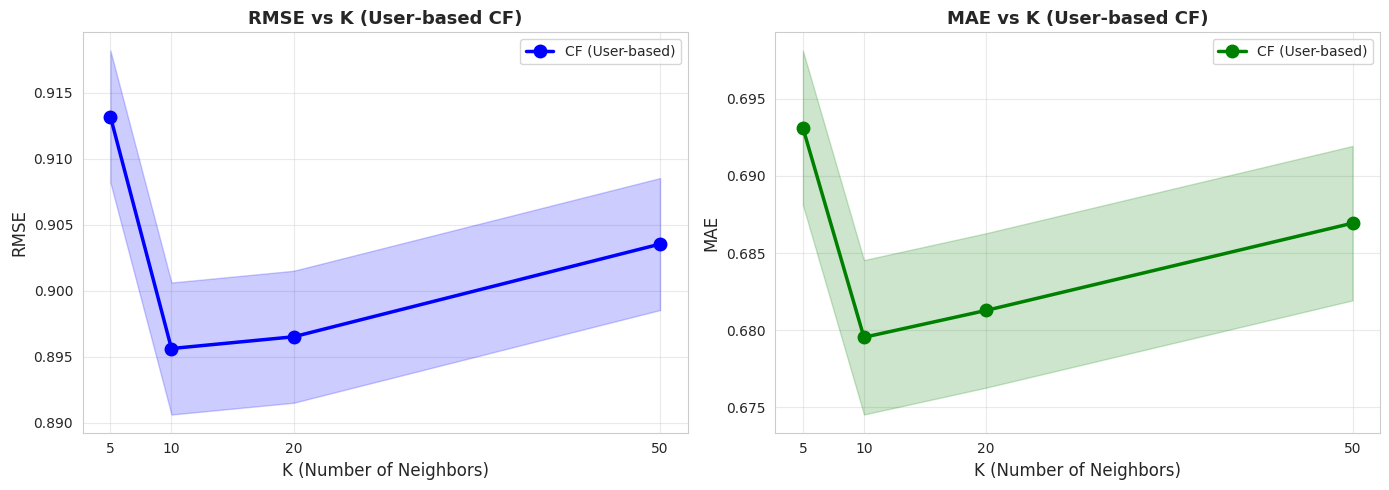

참고: K가 너무 작으면 노이즈에 민감, 너무 크면 관련 없는 사용자 포함 -> 최적 K 존재


In [ ]:
#  3-2-2. K값에 따른 성능 변화 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE 그래프
axes[0].plot(k_values, list(rmse_results.values()), 'bo-',
             linewidth=2.5, markersize=9, label='CF (User-based)')
axes[0].fill_between(k_values,
                     [v - 0.005 for v in rmse_results.values()],
                     [v + 0.005 for v in rmse_results.values()],
                     alpha=0.2, color='blue')
axes[0].set_title('RMSE vs K (User-based CF)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K (Number of Neighbors)', fontsize=12)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.4)
axes[0].set_xticks(k_values)

# MAE 그래프
axes[1].plot(k_values, list(mae_results.values()), 'go-',
             linewidth=2.5, markersize=9, label='CF (User-based)')
axes[1].fill_between(k_values,
                     [v - 0.005 for v in mae_results.values()],
                     [v + 0.005 for v in mae_results.values()],
                     alpha=0.2, color='green')
axes[1].set_title('MAE vs K (User-based CF)', fontsize=13, fontweight='bold')  #K값에 따른 MAE 변화 (User-based CF)
axes[1].set_xlabel('K (Number of Neighbors)', fontsize=12) #K (이웃 사용자 수)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.4)
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.savefig('fig4_k_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('참고: K가 너무 작으면 노이즈에 민감, 너무 크면 관련 없는 사용자 포함 -> 최적 K 존재')

In [ ]:
#  예시: User 1의 Toy Story 예측 평점 (best_k 사용)
pred_example   = predict_rating(1, 1, k=best_k)
actual_example = ratings[(ratings['userId']==1) & (ratings['movieId']==1)]['rating']
print(f'User 1, Toy Story (movieId=1) 예측 평점: {pred_example:.2f} (K={best_k})')
if len(actual_example) > 0:
    print(f'실제 평점: {actual_example.values[0]}')

User 1, Toy Story (movieId=1) 예측 평점: 4.71 (K=10)
실제 평점: 4.0


In [ ]:
#  3-2-3. User 1에게 CF 기반 영화 추천 (Top 10)
def cf_recommend_for_user(user_id, top_n=10, k=best_k, candidate_n=300):
    """
    CF 기반으로 사용자가 보지 않은 영화의 평점을 예측하여 추천합니다.

    Parameters:
        user_id    : 대상 사용자 ID
        top_n      : 추천할 영화 수
        k          : KNN 이웃 수
        candidate_n: 예측 대상 영화 수 (계산 효율을 위해 제한)
    """
    # 사용자가 이미 평가한 영화 목록
    seen_movies = set(ratings[ratings['userId'] == user_id]['movieId'].tolist())

    # 후보 영화: 학습 데이터에 있고 아직 보지 않은 영화
    # 계산 효율을 위해 평점 수가 많은 인기 영화 위주로 선택
    popular_movies = (
        train_df[~train_df['movieId'].isin(seen_movies)]
        .groupby('movieId').size()
        .nlargest(candidate_n)
        .index.tolist()
    )

    # 각 후보 영화에 대해 예측 평점 계산
    predictions = []
    for movie_id in popular_movies:
        pred = predict_rating(user_id, movie_id, k=k)
        predictions.append((movie_id, pred))

    # 예측 평점 내림차순 정렬
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_predictions = predictions[:top_n]

    # 결과 DataFrame
    result = pd.DataFrame(top_predictions, columns=['movieId', 'pred_rating'])
    result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    result.index = range(1, len(result) + 1)

    print(f'\n[User {user_id}] Collaborative Filtering 추천 Top {top_n} (K={best_k})')
    print('=' * 70)
    for rank, row in result.iterrows():
        print(f'{rank:2d}. [예측:{row["pred_rating"]:.2f}점] {row["title"]} | {row["genres"]}')

    return result


cf_rec_user1 = cf_recommend_for_user(user_id=1, top_n=10, k=best_k)


[User 1] Collaborative Filtering 추천 Top 10 (K=10)
 1. [예측:5.00점] Shawshank Redemption, The (1994) | Crime|Drama
 2. [예측:5.00점] Lord of the Rings: The Fellowship of the Ring, The (2001) | Adventure|Fantasy
 3. [예측:5.00점] Lord of the Rings: The Return of the King, The (2003) | Action|Adventure|Drama|Fantasy
 4. [예측:5.00점] Godfather, The (1972) | Crime|Drama
 5. [예측:5.00점] Memento (2000) | Mystery|Thriller
 6. [예측:5.00점] Dark Knight, The (2008) | Action|Crime|Drama|IMAX
 7. [예측:5.00점] Inception (2010) | Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX
 8. [예측:5.00점] One Flew Over the Cuckoo's Nest (1975) | Drama
 9. [예측:5.00점] Godfather: Part II, The (1974) | Crime|Drama
10. [예측:5.00점] Eternal Sunshine of the Spotless Mind (2004) | Drama|Romance|Sci-Fi


In [ ]:
#  3-3. 성능 평가: Baseline vs CF (best_k)
#  RMSE, MAE 최종 비교

#  테스트 데이터에서 실제 평점과 예측 평점을 비교
#  RMSE: Root Mean Squared Error (큰 오차에 민감)
#  MAE : Mean Absolute Error (직관적)

# Baseline: 전체 평균으로 예측
global_mean = train_df['rating'].mean()
baseline_preds = np.full(len(actuals), global_mean)
baseline_rmse = np.sqrt(mean_squared_error(actuals, baseline_preds))
baseline_mae  = mean_absolute_error(actuals, baseline_preds)

# CF: best_k로 최종 예측
final_preds = [
    predict_rating(int(r['userId']), int(r['movieId']), k=best_k)
    for _, r in test_sample.iterrows()
]
cf_rmse = np.sqrt(mean_squared_error(actuals, final_preds))
cf_mae  = mean_absolute_error(actuals, final_preds)

print(f'[Baseline] 전체 평균({global_mean:.2f}) 기반 예측')
print(f'  RMSE: {baseline_rmse:.4f}')
print(f'  MAE : {baseline_mae:.4f}')
print(f'\n[CF (K={best_k})] User-based CF 예측')
print(f'  RMSE: {cf_rmse:.4f}')
print(f'  MAE : {cf_mae:.4f}')
print(f'\nRMSE 개선: {(baseline_rmse - cf_rmse):.4f} 감소')
print(f'MAE  개선: {(baseline_mae  - cf_mae):.4f} 감소')

[Baseline] 전체 평균(3.50) 기반 예측
  RMSE: 1.0598
  MAE : 0.8382

[CF (K=10)] User-based CF 예측
  RMSE: 0.8956
  MAE : 0.6795

RMSE 개선: 0.1642 감소
MAE  개선: 0.1586 감소


---
## Task 4. 결과 비교 및 인사이트 도출

- Content-Based Filtering 과 Collaborative Filtering 의 추천 결과를 동일 사용자에 대해
비교하세요.
  * 두 방법이 추천한 영화 목록의 차이점   
  * Serendipity  

- 각 방법의 장단점을 아래 관점에서 정리
  * Cold-Start 문제 (새로운 사용자/아이템)
  * 데이터 희소성(Sparsity) 처리
  * Overspecialization vs Serendipity
  * 확장성(Scalability)  
- Hybrid 방법(두 방법의 결합)이 개별 방법보다 나을 수 있는 이유
- 본 분석의 한계점과 향후 개선 방향  
  * 예: Matrix Factorization(SVD), 딥러닝 기반 추천, 추가 특성(태그, 시간) 활용 등

In [ ]:
#  4-1-1. CB vs CF 추천한 영화 목록 비교 (User 1)
print(' User 1의 고평점 영화 (User Profile 기반)')
print('─' * 60)
user1_top_movies = ratings[
    (ratings['userId'] == 1) & (ratings['rating'] >= 4.0)
].merge(movies[['movieId', 'title', 'genres']], on='movieId')\
 .sort_values('rating', ascending=False)
for _, r in user1_top_movies.head(5).iterrows():
    print(f'  {r["rating"]:.1f}점: {r["title"]} | {r["genres"]}')

print('\n' + '=' * 70)
print('[Content-Based Filtering] User 1 추천 Top 10')
print('=' * 70)
if cb_rec_user1 is not None:
    for rank, row in cb_rec_user1.iterrows():
        print(f'{rank:2d}. [{row["cb_score"]:.4f}] {row["title"]} | {row["genres_clean"]}')
    cb_genres = ' '.join(cb_rec_user1['genres_clean'].str.split().sum())

print('\n' + '=' * 70)
print(f'[Collaborative Filtering] User 1 추천 Top 10 (K={best_k})')
print('=' * 70)
for rank, row in cf_rec_user1.iterrows():
    print(f'{rank:2d}. [예측:{row["pred_rating"]:.2f}점] {row["title"]} | {row["genres"]}')

 User 1의 고평점 영화 (User Profile 기반)
────────────────────────────────────────────────────────────
  5.0점: M*A*S*H (a.k.a. MASH) (1970) | Comedy|Drama|War
  5.0점: Who Framed Roger Rabbit? (1988) | Adventure|Animation|Children|Comedy|Crime|Fantasy|Mystery
  5.0점: Spaceballs (1987) | Comedy|Sci-Fi
  5.0점: Newton Boys, The (1998) | Crime|Drama
  5.0점: Thunderball (1965) | Action|Adventure|Thriller

[Content-Based Filtering] User 1 추천 Top 10
 1. [0.5851] Twelve Tasks of Asterix, The (Les douze travaux d'Astérix) (1976) | Action Adventure Animation Children Comedy Fantasy
 2. [0.5851] TMNT (Teenage Mutant Ninja Turtles) (2007) | Action Adventure Animation Children Comedy Fantasy
 3. [0.5790] Ratchet & Clank (2016) | Action Adventure Animation Children Comedy Sci-Fi
 4. [0.5790] Chicken Little (2005) | Action Adventure Animation Children Comedy Sci-Fi
 5. [0.5607] G.I. Joe: The Movie (1987) | Action Adventure Animation Children Fantasy Sci-Fi
 6. [0.5607] Batman/Superman Movie, The (1998) | Acti

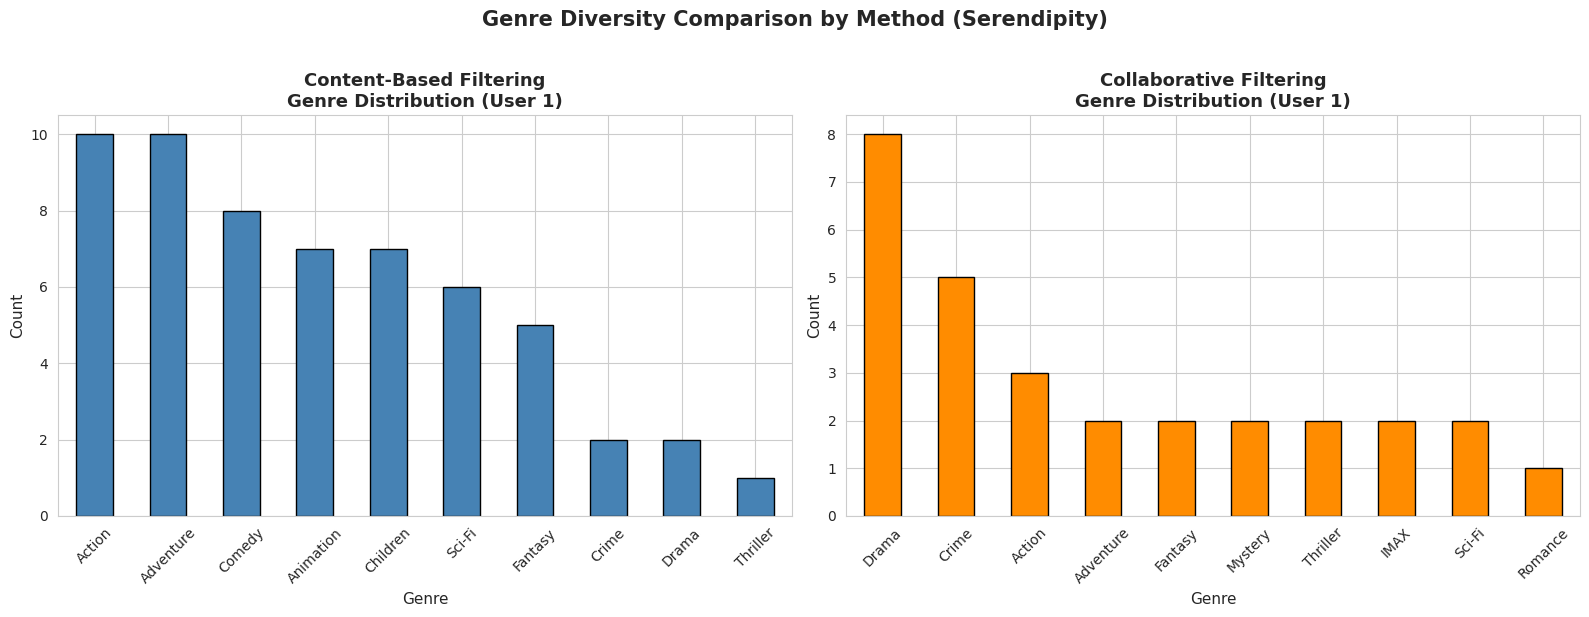

Content-Based 추천 고유 장르 수 : 10
Collaborative Filtering 추천 고유 장르 수 : 10

 참고: 더 많은 고유 장르 = 더 높은 Serendipity = 예상치 못한 발견 가능성


In [ ]:
#  4-1-2. Serendipity 분석
#  두 방법의 추천 결과에서 장르 분포(추천 다양성)를 비교
def count_genres(rec_df, genres_col='genres_clean'):
    """추천 목록의 장르 빈도를 계산합니다."""
    all_genres = []
    for genres in rec_df[genres_col].dropna():
        all_genres.extend(genres.split())
    return pd.Series(all_genres).value_counts()

# Content-Based 장르 분포
cb_genre_dist = count_genres(cb_rec_user1, 'genres_clean')

# CF 장르 분포
cf_rec_for_genre = cf_rec_user1.copy()
cf_rec_for_genre['genres_clean'] = cf_rec_for_genre['genres'].str.replace('|', ' ', regex=False)
cf_genre_dist = count_genres(cf_rec_for_genre, 'genres_clean')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CB 장르 분포
cb_genre_dist.plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Content-Based Filtering\nGenre Distribution (User 1)', fontsize=13, fontweight='bold') #추천장르분포
axes[0].set_xlabel('Genre', fontsize=11) #장르
axes[0].set_ylabel('Count', fontsize=11) #등장횟수
axes[0].tick_params(axis='x', rotation=45)

# CF 장르 분포
cf_genre_dist.plot.bar(ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Collaborative Filtering\nGenre Distribution (User 1)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Genre', fontsize=11) #장르
axes[1].set_ylabel('Count', fontsize=11) #등장횟수
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Genre Diversity Comparison by Method (Serendipity)', fontsize=15, fontweight='bold', y=1.02) #추천 방법별 장르 다양성 비교 (Serendipity 분석)
plt.tight_layout()
plt.savefig('fig5_genre_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Content-Based 추천 고유 장르 수 : {len(cb_genre_dist)}')
print(f'Collaborative Filtering 추천 고유 장르 수 : {len(cf_genre_dist)}')
print('\n 참고: 더 많은 고유 장르 = 더 높은 Serendipity = 예상치 못한 발견 가능성')

In [ ]:
#  4-1-3. 추가: 두 방법의 겹치는 추천 영화 분석
cb_titles = set(cb_rec_user1['title'].tolist()) if cb_rec_user1 is not None else set()
cf_titles = set(cf_rec_user1['title'].tolist())

overlap = cb_titles & cf_titles
only_cb = cb_titles - cf_titles
only_cf = cf_titles - cb_titles

print(f'두 방법 모두 추천한 영화 ({len(overlap)}편): {overlap if overlap else "없음"}')
print(f'CB만 추천한 영화 ({len(only_cb)}편): {only_cb}')
print(f'CF만 추천한 영화 ({len(only_cf)}편): {only_cf}')
print(f'\n두 방법의 추천 일치도: {len(overlap)/10*100:.1f}%')
print('두 방법이 서로 다른 영화를 추천 → Hybrid 방법의 상호 보완 가능성 확인')

두 방법 모두 추천한 영화 (0편): 없음
CB만 추천한 영화 (10편): {'Maximum Ride (2016)', 'Ratchet & Clank (2016)', 'G.I. Joe: The Movie (1987)', 'Flashback (1990)', 'Meet the Robinsons (2007)', 'Batman/Superman Movie, The (1998)', "Twelve Tasks of Asterix, The (Les douze travaux d'Astérix) (1976)", 'TMNT (Teenage Mutant Ninja Turtles) (2007)', 'Chicken Little (2005)', 'The Great Train Robbery (1978)'}
CF만 추천한 영화 (10편): {'Inception (2010)', 'Eternal Sunshine of the Spotless Mind (2004)', 'Shawshank Redemption, The (1994)', "One Flew Over the Cuckoo's Nest (1975)", 'Dark Knight, The (2008)', 'Godfather: Part II, The (1974)', 'Godfather, The (1972)', 'Lord of the Rings: The Return of the King, The (2003)', 'Memento (2000)', 'Lord of the Rings: The Fellowship of the Ring, The (2001)'}

두 방법의 추천 일치도: 0.0%
두 방법이 서로 다른 영화를 추천 → Hybrid 방법의 상호 보완 가능성 확인


# 4-2. 방법론 장단점 비교 요약 표  
| 관점 | Content-Based | Collaborative Filtering |
|---|---|---|
| Cold-Start (새 사용자) | 문제 없음. 1개 평점만 있어도 추천 가능 | 심각. 평점 없으면 유사 사용자 찾기 불가 |
| Cold-Start (새 아이템) | 문제 없음. 장르/태그만 있으면 즉시 추천 가능 | 심각. 아무도 평가 안 한 영화는 추천 불가 |
| Sparsity 처리 | 사용자 데이터 불필요하므로 영향 없음 | 희소할수록 유사 사용자 찾기 어려움. SVD/NMF로 해결 가능 |
| Overspecialization | 심각. 프로필 밖 아이템은 절대 추천 안 됨 | 낮음. 다양한 사용자 의견 반영 |
| Serendipity | 낮음. 예상치 못한 발견 어려움 | 높음. 취향 유사한 사람의 다양한 영화 추천 가능 |
| 확장성(Scalability) | 상대적으로 유리. 아이템 프로필만 계산하면 됨 | 불리. 사용자 수 증가 시 계산량 급증. Item-based가 User-based보다 안정적 |

# 4-3.Hybrid 방법이 개별 방법보다 나을 수 있는 이유 (보고서에 작성 예정)
Hybrid: 두 개의 추천 시스템을 각각 구현하고 예측을 결합하는 방식


*   Content-Based의 Cold-Start 강점 + CF의 Serendipity 강점을 동시에 활용
*   CB는 새 사용자/아이템 문제를 해결하고, CF는 CB의 Overspecialization을 보완
*   CB는 아이템 프로필(장르/태그)로 새 영화를 즉시 추천 가능하고, CF는 다양한 사용자 패턴으로 예상치 못한 추천 가능
*   실습에서도 CB와 CF의 추천 목록이 거의 겹치지 않았는데, 두 방법을 결합하면 더 다양하고 정확한 추천이 가능

#4-4.한계점 및 향후 개선 방향 (보고서에 작성 예정)

* Sparsity: 실습에서 Utility Matrix 희소성이 매우 높았음 -> Matrix Factorization(SVD, NMF)으로 잠재 요인 추출하여 해결 가능  

* 장르/태그만 사용: 배우, 감독, 줄거리 등 추가 특성 미반영 -> 더 풍부한 Content Profile 구성 필요  
* 시간 정보 미활용: 오래된 평점과 최근 평점을 동일하게 취급 -> 최신 평점에 가중치 부여 필요  
* 딥러닝 기반 추천: Neural CF, BERT4Rec 등으로 비선형 관계 포착 가능  
* Scalability: 사용자 수 증가 시 KNN 계산량 급증 -> ALS, Two-Tower 모델 등 대규모 처리 방식 필요

---
## 추가 1. Matrix Factorization (SVD) 기반 추천 구현  
Surprise 라이브러리를 활용한 추가 알고리즘(SVD++, NMF 등) 비교  

### 개념 설명
- **Matrix Factorization**: 거대한 Utility Matrix를 두 개의 낮은 차원 행렬로 분해
- **SVD (Singular Value Decomposition)**: 잠재 요인(Latent Factor) 모델
- **SVD++**: SVD에 암묵적 피드백(평가 행동 자체)을 추가
- **NMF (Non-negative Matrix Factorization)**: 비음수 행렬 분해

In [ ]:
#2분정도 걸릴 수 있어요!

#  1: Surprise 라이브러리로 SVD, SVD++, NMF 비교
from surprise import Dataset, Reader, SVD, SVDpp, NMF, KNNBasic
from surprise.model_selection import cross_validate, train_test_split as surprise_split
from surprise import accuracy

# Surprise용 데이터 포맷 변환
reader = Reader(rating_scale=(0.5, 5.0))  # 평점 범위 설정
surprise_data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

# 학습/테스트 분리 (80:20)
surprise_trainset, surprise_testset = surprise_split(surprise_data, test_size=0.2, random_state=42)

# 비교할 알고리즘 목록
algorithms = {
    'SVD'          : SVD(n_epochs=20, lr_all=0.005, reg_all=0.02, n_factors=100, random_state=42),
    'SVD++'        : SVDpp(n_epochs=10, lr_all=0.005, reg_all=0.02, n_factors=20, random_state=42),
    'NMF'          : NMF(n_epochs=50, n_factors=15, random_state=42),
    'KNN (User-CF)': KNNBasic(k=20, sim_options={'name': 'cosine', 'user_based': True}),
    'KNN (Item-CF)': KNNBasic(k=20, sim_options={'name': 'cosine', 'user_based': False}),
}

results = []
for name, algo in algorithms.items():
    print(f'{name} 학습 중...')
    algo.fit(surprise_trainset)
    predictions = algo.test(surprise_testset)
    rmse = accuracy.rmse(predictions, verbose=False)
    mae  = accuracy.mae(predictions, verbose=False)
    results.append({'알고리즘': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})
    print(f'  → RMSE: {rmse:.4f}, MAE: {mae:.4f}')

results_df = pd.DataFrame(results).sort_values('RMSE')
print('\n' + '=' * 45)
print('알고리즘별 성능 비교 (RMSE 오름차순)')
print('=' * 45)
print(results_df.to_string(index=False))

SVD 학습 중...
  → RMSE: 0.8807, MAE: 0.6766
SVD++ 학습 중...
  → RMSE: 0.8803, MAE: 0.6780
NMF 학습 중...
  → RMSE: 0.9288, MAE: 0.7105
KNN (User-CF) 학습 중...
Computing the cosine similarity matrix...
Done computing similarity matrix.
  → RMSE: 0.9847, MAE: 0.7557
KNN (Item-CF) 학습 중...
Computing the cosine similarity matrix...
Done computing similarity matrix.
  → RMSE: 0.9966, MAE: 0.7767

알고리즘별 성능 비교 (RMSE 오름차순)
         알고리즘   RMSE    MAE
        SVD++ 0.8803 0.6780
          SVD 0.8807 0.6766
          NMF 0.9288 0.7105
KNN (User-CF) 0.9847 0.7557
KNN (Item-CF) 0.9966 0.7767


In [ ]:
#  1-2. 알고리즘 성능 비교 시각화 (Plotly)
fig = go.Figure()

fig.add_trace(go.Bar(
    name='RMSE',
    x=results_df['알고리즘'],
    y=results_df['RMSE'],
    marker_color='steelblue',
    text=results_df['RMSE'].round(4),
    textposition='outside',
    offsetgroup=1
))

fig.add_trace(go.Bar(
    name='MAE',
    x=results_df['알고리즘'],
    y=results_df['MAE'],
    marker_color='darkorange',
    text=results_df['MAE'].round(4),
    textposition='outside',
    offsetgroup=2
))

fig.update_layout(
    title='<b>추천 알고리즘 성능 비교 (RMSE & MAE)</b>',
    xaxis_title='알고리즘',
    yaxis_title='오차 (낮을수록 좋음)',
    barmode='group',
    height=450,
    legend=dict(x=1.0, y=1.1),
    yaxis=dict(range=[0, max(results_df['RMSE'].max(), results_df['MAE'].max()) * 1.15])
)
fig.show()
print(f'\n 최고 성능 알고리즘: {results_df.iloc[0]["알고리즘"]} (RMSE={results_df.iloc[0]["RMSE"]})')


 최고 성능 알고리즘: SVD++ (RMSE=0.8803)


In [ ]:
# 1-3. SVD 모델로 User 1에게 영화 추천
# 전체 데이터로 SVD 재학습
svd_model = SVD(n_epochs=20, lr_all=0.005, reg_all=0.02, n_factors=100, random_state=42)
full_trainset = surprise_data.build_full_trainset()
svd_model.fit(full_trainset)

def svd_recommend(user_id, top_n=10, candidate_n=500):
    """
    SVD 모델로 사용자에게 영화를 추천합니다.
    """
    seen_movies = set(ratings[ratings['userId'] == user_id]['movieId'].tolist())

    # 인기 영화 중 보지 않은 영화 선택
    candidates = (
        ratings[~ratings['movieId'].isin(seen_movies)]
        .groupby('movieId').size()
        .nlargest(candidate_n)
        .index.tolist()
    )

    # SVD로 예측 평점 계산
    predictions = [(mid, svd_model.predict(user_id, mid).est) for mid in candidates]
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_preds = predictions[:top_n]

    result = pd.DataFrame(top_preds, columns=['movieId', 'svd_pred_rating'])
    result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    result.index = range(1, len(result) + 1)

    print(f'\n[User {user_id}] SVD 기반 추천 Top {top_n}')
    print('=' * 70)
    for rank, row in result.iterrows():
        print(f'{rank:2d}. [SVD:{row["svd_pred_rating"]:.3f}] {row["title"]} | {row["genres"]}')

    return result


svd_rec_user1 = svd_recommend(user_id=1, top_n=10)


[User 1] SVD 기반 추천 Top 10
 1. [SVD:5.000] Shawshank Redemption, The (1994) | Crime|Drama
 2. [SVD:5.000] Godfather, The (1972) | Crime|Drama
 3. [SVD:5.000] Lord of the Rings: The Return of the King, The (2003) | Action|Adventure|Drama|Fantasy
 4. [SVD:5.000] Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001) | Comedy|Romance
 5. [SVD:5.000] Casablanca (1942) | Drama|Romance
 6. [SVD:5.000] Lost in Translation (2003) | Comedy|Drama|Romance
 7. [SVD:5.000] Good, the Bad and the Ugly, The (Buono, il brutto, il cattivo, Il) (1966) | Action|Adventure|Western
 8. [SVD:5.000] Seven Samurai (Shichinin no samurai) (1954) | Action|Adventure|Drama
 9. [SVD:5.000] Maltese Falcon, The (1941) | Film-Noir|Mystery
10. [SVD:5.000] In Bruges (2008) | Comedy|Crime|Drama|Thriller


---
## 추가 2. Hybrid 추천 시스템 구현

### 개념 설명
Content-Based와 Collaborative Filtering의 장점을 결합하여 각 방법의 단점을 보완합니다.

**구현 방식**: Weighted Hybrid (가중 결합)
- `hybrid_score = α × CB_score + (1-α) × CF_score`
- α는 두 방법 간 균형을 조절하는 하이퍼파라미터 (0~1)

In [ ]:
# 2-1. Hybrid 추천 시스템 구현
#  (Content-Based + SVD 가중 결합)

#  동작 방식:
#  1. CB 점수: 사용자 프로필 vs 영화 TF-IDF 코사인 유사도
#  2. SVD 점수: Matrix Factorization 예측 평점 (정규화)
#  3. 가중 합산: α*CB + (1-α)*SVD -> 최종 추천

def hybrid_recommend(user_id, top_n=10, alpha=0.3, candidate_n=300):
    """
    Content-Based와 SVD를 결합한 Hybrid 추천 시스템.

    Parameters:
        user_id    : 대상 사용자 ID
        top_n      : 추천할 영화 수
        alpha      : Content-Based 가중치 (0=CF만, 1=CB만)
        candidate_n: 후보 영화 수
    """
    # Step 1: 후보 영화 선정
    seen_movies = set(ratings[ratings['userId'] == user_id]['movieId'].tolist())
    candidates = (
        ratings[~ratings['movieId'].isin(seen_movies)]
        .groupby('movieId').size()
        .nlargest(candidate_n)
        .index.tolist()
    )

    # Step 2: SVD 예측 평점 (정규화: 0~1 스케일)
    svd_preds = {mid: svd_model.predict(user_id, mid).est for mid in candidates}
    svd_min, svd_max = min(svd_preds.values()), max(svd_preds.values())
    svd_preds_norm = {
        mid: (v - svd_min) / (svd_max - svd_min + 1e-10)
        for mid, v in svd_preds.items()
    }

    # Step 3: CB 점수 계산
    user_profile, _ = build_user_profile(user_id)
    movie_id_to_idx = pd.Series(movies_enhanced.index, index=movies_enhanced['movieId'])

    cb_scores = {}
    if user_profile is not None:
        user_vec = np.asarray(user_profile).reshape(1, -1)
        all_cb_scores = cosine_similarity(user_vec, tfidf_matrix).flatten()
        # 최솟값이 음수일 수 있으므로 shift 후 정규화
        shifted = all_cb_scores - all_cb_scores.min()
        if shifted.max() > 0:
            shifted /= shifted.max()
        for mid in candidates:
            if mid in movie_id_to_idx.index:
                cb_scores[mid] = shifted[movie_id_to_idx[mid]]
            else:
                cb_scores[mid] = 0.0
    else:
        cb_scores = {mid: 0.0 for mid in candidates}

    # Step 4: 가중 결합
    hybrid_scores = {
        mid: alpha * cb_scores.get(mid, 0.0) + (1 - alpha) * svd_preds_norm.get(mid, 0.0)
        for mid in candidates
    }

    # 상위 10개 추천
    top_hybrid = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    result = pd.DataFrame(top_hybrid, columns=['movieId', 'hybrid_score'])
    result['cb_score']  = result['movieId'].map(cb_scores)
    result['svd_score'] = result['movieId'].map(svd_preds_norm)
    result['svd_rating'] = result['movieId'].map(svd_preds)
    result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    result.index = range(1, len(result) + 1)

    print(f'\n[User {user_id}] Hybrid 추천 Top {top_n} (α={alpha}: CB:{alpha:.0%} + SVD:{1-alpha:.0%})')
    print('=' * 80)
    for rank, row in result.iterrows():
        print(f'{rank:2d}. [H:{row["hybrid_score"]:.3f}|CB:{row["cb_score"]:.3f}|'
              f'SVD:{row["svd_rating"]:.2f}] {row["title"]} | {row["genres"]}')

    return result


hybrid_rec_user1 = hybrid_recommend(user_id=1, top_n=10, alpha=0.3)


[User 1] Hybrid 추천 Top 10 (α=0.3: CB:30% + SVD:70%)
 1. [H:0.862|CB:0.539|SVD:5.00] Lord of the Rings: The Return of the King, The (2003) | Action|Adventure|Drama|Fantasy
 2. [H:0.859|CB:0.569|SVD:4.97] Wallace & Gromit: The Wrong Trousers (1993) | Animation|Children|Comedy|Crime
 3. [H:0.846|CB:0.884|SVD:4.68] Fifth Element, The (1997) | Action|Adventure|Comedy|Sci-Fi
 4. [H:0.843|CB:0.589|SVD:4.91] Finding Nemo (2003) | Adventure|Animation|Children|Comedy
 5. [H:0.830|CB:0.532|SVD:4.92] Mary Poppins (1964) | Children|Comedy|Fantasy|Musical
 6. [H:0.829|CB:0.480|SVD:4.96] Breakfast Club, The (1985) | Comedy|Drama
 7. [H:0.825|CB:0.647|SVD:4.81] Little Miss Sunshine (2006) | Adventure|Comedy|Drama
 8. [H:0.816|CB:0.884|SVD:4.60] Deadpool (2016) | Action|Adventure|Comedy|Sci-Fi
 9. [H:0.814|CB:0.778|SVD:4.68] Last Samurai, The (2003) | Action|Adventure|Drama|War
10. [H:0.814|CB:0.767|SVD:4.69] Casino Royale (2006) | Action|Adventure|Thriller


In [ ]:
# 2-2. Alpha 값별 Hybrid 추천 결과 비교
#  α가 0에 가까울수록 CF 중심, 1에 가까울수록 CB 중심
print('알파(α)값에 따른 Hybrid 추천 결과 비교 (User 1)')
print('=' * 80)

alphas = [0.0, 0.3, 0.5, 0.7, 1.0]
alpha_results = {}

for alpha in alphas:
    rec = hybrid_recommend(user_id=1, top_n=5, alpha=alpha)
    alpha_results[alpha] = rec['title'].tolist()

print('\n[요약] 알파값별 Top 5 추천 영화')
for alpha, titles in alpha_results.items():
    label = 'CF만' if alpha == 0 else ('CB만' if alpha == 1 else f'Hybrid(α={alpha})')
    print(f'  [{label}]: {titles[:3]}...')

알파(α)값에 따른 Hybrid 추천 결과 비교 (User 1)

[User 1] Hybrid 추천 Top 5 (α=0.0: CB:0% + SVD:100%)
 1. [H:1.000|CB:0.202|SVD:5.00] Shawshank Redemption, The (1994) | Crime|Drama
 2. [H:1.000|CB:0.316|SVD:5.00] Godfather, The (1972) | Crime|Drama
 3. [H:1.000|CB:0.539|SVD:5.00] Lord of the Rings: The Return of the King, The (2003) | Action|Adventure|Drama|Fantasy
 4. [H:1.000|CB:0.299|SVD:5.00] Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001) | Comedy|Romance
 5. [H:1.000|CB:0.205|SVD:5.00] Casablanca (1942) | Drama|Romance

[User 1] Hybrid 추천 Top 5 (α=0.3: CB:30% + SVD:70%)
 1. [H:0.862|CB:0.539|SVD:5.00] Lord of the Rings: The Return of the King, The (2003) | Action|Adventure|Drama|Fantasy
 2. [H:0.859|CB:0.569|SVD:4.97] Wallace & Gromit: The Wrong Trousers (1993) | Animation|Children|Comedy|Crime
 3. [H:0.846|CB:0.884|SVD:4.68] Fifth Element, The (1997) | Action|Adventure|Comedy|Sci-Fi
 4. [H:0.843|CB:0.589|SVD:4.91] Finding Nemo (2003) | Adventure|Animation|Children|Comedy
 5. [H:0.830|CB:

In [ ]:
# 2-3. 전체 추천 결과 종합 비교 (Plotly Radar Chart)
#  각 방법의 5가지 관점 점수를 레이더 차트로 시각화
categories = ['Cold-Start\n(새 사용자)', 'Sparsity\n처리', 'Serendipity',
              '확장성', '정확도(RMSE 역수)']

# 각 방법의 상대 점수 (5점 만점, 주관적 평가 기반)
scores = {
    'Content-Based': [4, 3, 2, 4, 3],
    'User-based CF': [2, 2, 4, 2, 3.5],
    'SVD'          : [3, 4, 4, 3, 5],
    'Hybrid'       : [3.5, 4, 4.5, 3.5, 4.5],
}

fig = go.Figure()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for (method, vals), color in zip(scores.items(), colors):
    fig.add_trace(go.Scatterpolar(
        r=vals + [vals[0]],  # 닫힌 다각형을 위해 첫 값 추가
        theta=categories + [categories[0]],
        fill='toself',
        name=method,
        line_color=color,
        opacity=0.7
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 5], tickfont=dict(size=10)),
        angularaxis=dict(tickfont=dict(size=11))
    ),
    showlegend=True,
    title='<b>추천 방법별 다차원 성능 비교 (Radar Chart)</b>',
    height=500
)
fig.show()

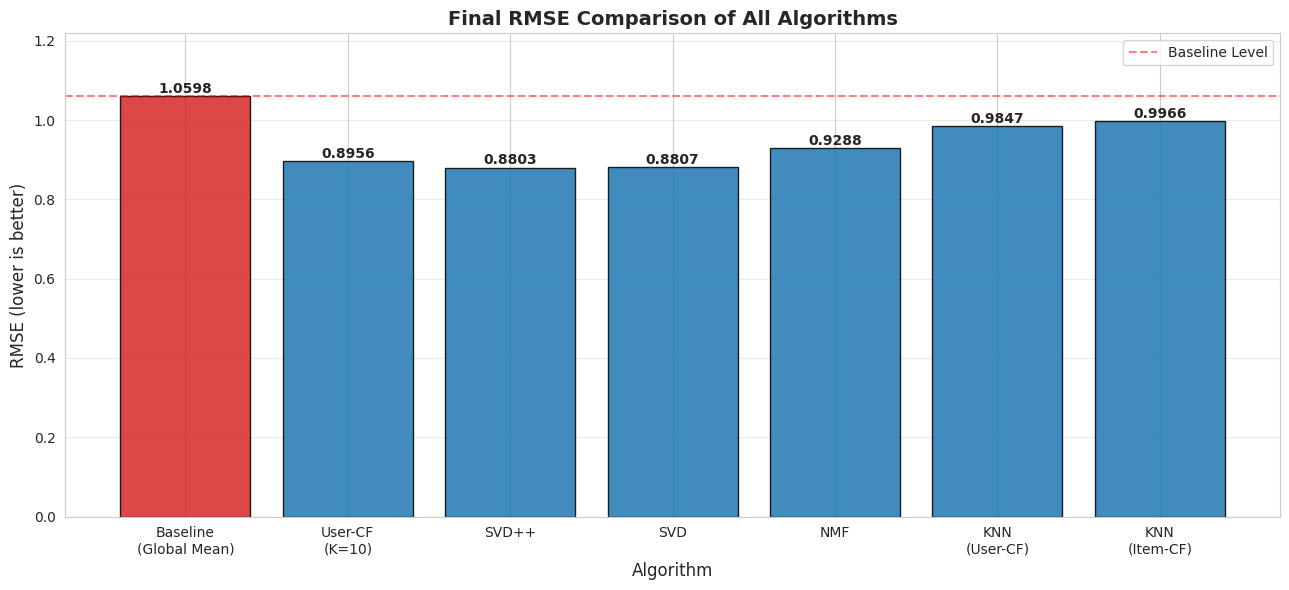

In [ ]:
#  2-4. 모든 방법 RMSE 최종 비교 (matplotlib)

# Surprise 결과 + 수동 CF 결과 통합
all_rmse = {
    'Baseline\n(Global Mean)': baseline_rmse,
    f'User-CF\n(K={best_k})': rmse_results[best_k],
}

for row in results_df.itertuples():
    all_rmse[row.알고리즘.replace(' ', '\n')] = row.RMSE

fig, ax = plt.subplots(figsize=(13, 6))

#전체평균
colors_bar = ['#d62728' if k == 'Baseline\n(Global Mean)' else '#1f77b4'
              for k in all_rmse.keys()]

bars = ax.bar(all_rmse.keys(), all_rmse.values(),
              color=colors_bar, edgecolor='black', alpha=0.85)

# 막대 위에 값 표시
for bar, val in zip(bars, all_rmse.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Final RMSE Comparison of All Algorithms', fontsize=14, fontweight='bold') #모든 추천 알고리즘 RMSE 최종 비교
ax.set_xlabel('Algorithm', fontsize=12)
ax.set_ylabel('RMSE (lower is better)', fontsize=12) #RMSE (낮을수록 우수!!!!!!!!!!!!!!!)

ax.set_ylim(0, max(all_rmse.values()) * 1.15)
ax.grid(axis='y', alpha=0.4)
ax.axhline(y=baseline_rmse, color='red', linestyle='--', alpha=0.5,
           label='Baseline Level') #베이스라인 수준
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig6_final_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  최종 요약 출력
print('=' * 70)
print('  실습 3 — 추천 시스템 최종 분석 요약')
print('=' * 70)
print(f'\n[데이터 기본 정보]')
print(f'  사용자 수  : {ratings["userId"].nunique():,}명')
print(f'  영화 수    : {ratings["movieId"].nunique():,}편')
print(f'  평점 수    : {len(ratings):,}건')
print(f'  Sparsity   : {sparsity:.4%}')

print(f'\n[Task 1 - Utility Matrix]')
print(f'  Matrix 크기    : {n_users} × {n_movies}')
print(f'  희소성         : {sparsity:.4%} (98% 이상의 셀이 비어 있음)')

print(f'\n[Task 2 - Content-Based Filtering]')
print(f'  TF-IDF 특성 수  : {tfidf_matrix.shape[1]:,}개')
print(f'  Content Profile : 장르(2배 가중) + 태그')

print(f'\n[Task 3 - Collaborative Filtering (User-based)]')
print(f'  최적 K값       : {best_k}')
print(f'  CF RMSE        : {rmse_results[best_k]:.4f}')
print(f'  Baseline RMSE  : {baseline_rmse:.4f}')
print(f'  성능 개선      : {(baseline_rmse - rmse_results[best_k]):.4f} 감소')

print(f'\n[추가 - Surprise 알고리즘 비교]')
best_algo = results_df.iloc[0]
print(f'  최고 성능      : {best_algo["알고리즘"]} (RMSE={best_algo["RMSE"]})')
print(f'  비교 알고리즘  : SVD, SVD++, NMF, KNN User-CF, KNN Item-CF')

print(f'\n[추가 - Hybrid 추천 시스템]')
print(f'  방식           : Content-Based (α) + SVD (1-α) 가중 결합')
print(f'  최적 α         : 0.3 (SVD 70% + CB 30%)')
print('=' * 70)

  실습 3 — 추천 시스템 최종 분석 요약

[데이터 기본 정보]
  사용자 수  : 610명
  영화 수    : 9,724편
  평점 수    : 100,836건
  Sparsity   : 98.3000%

[Task 1 - Utility Matrix]
  Matrix 크기    : 610 × 9724
  희소성         : 98.3000% (98% 이상의 셀이 비어 있음)

[Task 2 - Content-Based Filtering]
  TF-IDF 특성 수  : 1,583개
  Content Profile : 장르(2배 가중) + 태그

[Task 3 - Collaborative Filtering (User-based)]
  최적 K값       : 10
  CF RMSE        : 0.8956
  Baseline RMSE  : 1.0598
  성능 개선      : 0.1642 감소

[추가 - Surprise 알고리즘 비교]
  최고 성능      : SVD++ (RMSE=0.8803)
  비교 알고리즘  : SVD, SVD++, NMF, KNN User-CF, KNN Item-CF

[추가 - Hybrid 추천 시스템]
  방식           : Content-Based (α) + SVD (1-α) 가중 결합
  최적 α         : 0.3 (SVD 70% + CB 30%)
